## cosine similarity measurement

### import packages

In [2]:
import os
import time
import datetime
import pickle

import numpy as np

import matplotlib.pyplot as plt

import torch
from torch import nn
from torch import linalg as LA
import torch.nn.functional as F

### define functions

In [3]:
def similarity(X, X1):
    #out = torch.matmul(X, X1.T) / (LA.norm(X) * LA.norm(X1))
    out = torch.matmul(X, X1.T) #since LA.norm(X)==1
    return out.item()

### load data

In [5]:
filename_valid = './data/vs_valid1k.pkl'
with open(filename_valid, 'rb') as handle:
    valid = pickle.load(handle)

In [6]:
vs_valid = []
for k, v in valid.items():
    vs_valid.append(v[1])
vs_valid = torch.cat(vs_valid)  

### 1. measure similarity all pairs Nx(N-1)/2 based on fp32

(array([2.0000e+00, 7.0000e+00, 4.0000e+00, 9.0000e+00, 2.4000e+01,
        3.2000e+01, 5.8000e+01, 8.0000e+01, 1.1200e+02, 2.0100e+02,
        2.3800e+02, 4.0800e+02, 5.8300e+02, 8.0300e+02, 1.1320e+03,
        1.6570e+03, 2.2850e+03, 3.0800e+03, 4.0870e+03, 5.3510e+03,
        6.7100e+03, 8.5430e+03, 1.0405e+04, 1.2472e+04, 1.4383e+04,
        1.6590e+04, 1.8410e+04, 2.0266e+04, 2.2020e+04, 2.3362e+04,
        2.3969e+04, 2.4297e+04, 2.4014e+04, 2.3610e+04, 2.3180e+04,
        2.1635e+04, 2.0781e+04, 1.9197e+04, 1.7869e+04, 1.6188e+04,
        1.4592e+04, 1.2970e+04, 1.1489e+04, 1.0391e+04, 9.0150e+03,
        7.7930e+03, 7.0080e+03, 5.8810e+03, 5.0980e+03, 4.5210e+03,
        3.8030e+03, 3.1770e+03, 2.7580e+03, 2.2600e+03, 1.8480e+03,
        1.6300e+03, 1.3370e+03, 1.0550e+03, 8.8600e+02, 7.5400e+02,
        6.1800e+02, 5.0400e+02, 3.9500e+02, 3.2100e+02, 2.5500e+02,
        2.1900e+02, 1.7000e+02, 1.2800e+02, 1.1100e+02, 1.0400e+02,
        7.5000e+01, 6.3000e+01, 4.1000e+01, 2.90

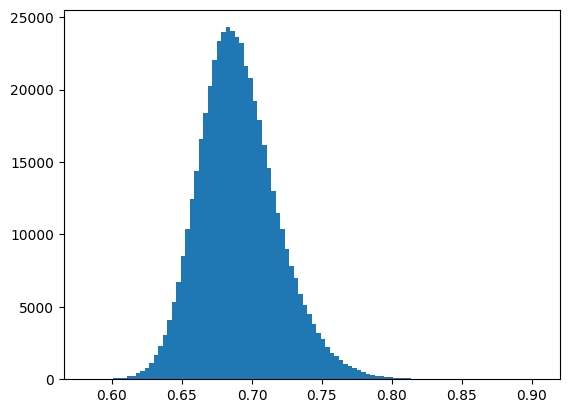

In [7]:
score_fp32 = []
for i in range(len(vs_valid)):
    for j in range(i+1, len(vs_valid)):
        score_fp32.append(similarity(vs_valid[i:i+1], vs_valid[j:j+1]))
                
plt.hist(score_fp32, bins=100)                

### 2. measure similarity all pairs Nx(N-1)/2 based on bf16

(array([2.0000e+00, 6.0000e+00, 8.0000e+00, 1.4000e+01, 2.9000e+01,
        0.0000e+00, 6.1000e+01, 9.1000e+01, 1.6000e+02, 2.4700e+02,
        3.6500e+02, 0.0000e+00, 6.8700e+02, 9.3800e+02, 1.4930e+03,
        2.2870e+03, 0.0000e+00, 3.3990e+03, 4.6390e+03, 6.5800e+03,
        8.7630e+03, 1.1323e+04, 0.0000e+00, 1.4430e+04, 1.7095e+04,
        2.0463e+04, 2.3018e+04, 0.0000e+00, 2.5621e+04, 2.8014e+04,
        2.9008e+04, 2.9506e+04, 2.8839e+04, 0.0000e+00, 2.8325e+04,
        2.6986e+04, 2.4965e+04, 2.2727e+04, 0.0000e+00, 2.0793e+04,
        1.8340e+04, 1.6040e+04, 1.3897e+04, 1.2040e+04, 0.0000e+00,
        1.0150e+04, 8.7520e+03, 7.2430e+03, 6.1140e+03, 0.0000e+00,
        5.1680e+03, 4.1580e+03, 3.4590e+03, 2.7370e+03, 2.2000e+03,
        0.0000e+00, 1.7950e+03, 1.4400e+03, 1.1180e+03, 8.9700e+02,
        7.0900e+02, 0.0000e+00, 5.5500e+02, 4.0900e+02, 3.0800e+02,
        2.4900e+02, 0.0000e+00, 2.0400e+02, 1.4100e+02, 1.2800e+02,
        9.0000e+01, 7.2000e+01, 0.0000e+00, 4.00

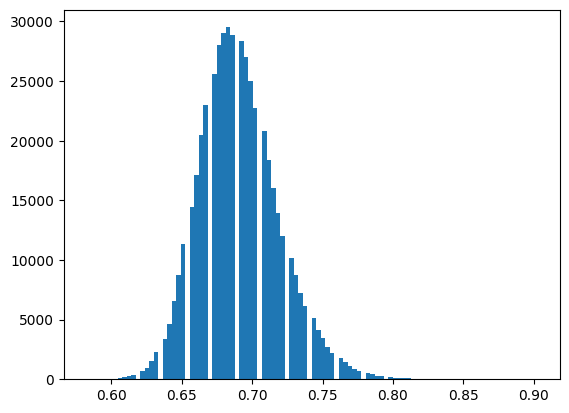

In [8]:
score_bf16 = []
for i in range(len(vs_valid)):
    for j in range(i+1, len(vs_valid)):
        score_bf16.append(similarity(vs_valid[i:i+1].to(torch.bfloat16), vs_valid[j:j+1].to(torch.bfloat16)))
                
plt.hist(score_bf16, bins=100)     

### 3. measure similarity all pairs Nx(N-1)/2 based on int8/bf16

In [9]:
def quantint8(w_fp32):
    scales = w_fp32.abs().max(dim=-1).values / 127  #2**(8-1)-1
    scales = scales.to(torch.bfloat16)

    w_int8 = torch.round(w_fp32
                    /scales.unsqueeze(1)).to(torch.int8)

    return w_int8, scales 

(array([1.0000e+00, 6.0000e+00, 1.0000e+01, 1.4000e+01, 3.8000e+01,
        6.5000e+01, 0.0000e+00, 1.0200e+02, 1.4500e+02, 2.5100e+02,
        4.1600e+02, 7.9700e+02, 0.0000e+00, 1.1430e+03, 1.6270e+03,
        2.6150e+03, 3.1770e+03, 4.5830e+03, 0.0000e+00, 6.3980e+03,
        9.0930e+03, 1.0833e+04, 1.5012e+04, 1.7464e+04, 0.0000e+00,
        2.0366e+04, 2.3654e+04, 2.7324e+04, 2.5018e+04, 3.0628e+04,
        2.5252e+04, 0.0000e+00, 3.0393e+04, 2.9381e+04, 2.9717e+04,
        2.0909e+04, 2.3572e+04, 0.0000e+00, 1.8951e+04, 2.1138e+04,
        1.4743e+04, 1.5073e+04, 1.0372e+04, 0.0000e+00, 1.0688e+04,
        9.9190e+03, 7.0490e+03, 5.5630e+03, 4.5670e+03, 0.0000e+00,
        4.7770e+03, 3.9480e+03, 2.3660e+03, 1.5470e+03, 2.1210e+03,
        1.7000e+03, 0.0000e+00, 1.2860e+03, 4.8800e+02, 6.5800e+02,
        6.8400e+02, 5.0600e+02, 0.0000e+00, 3.5900e+02, 5.8000e+01,
        2.4600e+02, 1.9400e+02, 1.5900e+02, 0.0000e+00, 3.0000e+01,
        8.0000e+01, 5.9000e+01, 4.6000e+01, 2.70

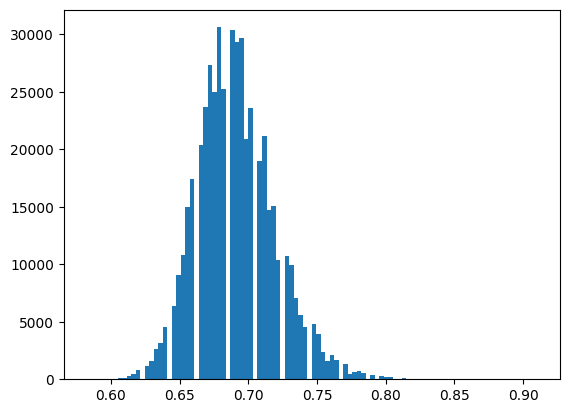

In [10]:
score_int8 = []
for i in range(len(vs_valid)):
    for j in range(i+1, len(vs_valid)):
        V1,S1 = quantint8(vs_valid[i:i+1])
        V2,S2 = quantint8(vs_valid[j:j+1])
        score_int8.append((torch.matmul(V1.to(torch.bfloat16), V2.to(torch.bfloat16).T)*S1*S2).item()) 
               
plt.hist(score_int8, bins=100)     

### 4. measure similarity all pairs Nx(N-1)/2 based on int4/bf16
#### 4-1. symmetric and group quantization (group_size=32)

In [12]:
def quantint4(tensor, group_size = 128):
    tensor = tensor.view(-1, group_size)
    scales = tensor.abs().max(dim=-1).values / 7  #2**(4-1)-1
    scales = scales.to(torch.bfloat16)

    quantized_tensor = torch.round(tensor
                    /scales.unsqueeze(1)).to(torch.int8)

    return quantized_tensor, scales   


(array([7.0000e+00, 5.0000e+00, 1.5000e+01, 2.3000e+01, 0.0000e+00,
        5.4000e+01, 8.2000e+01, 1.4700e+02, 2.1400e+02, 0.0000e+00,
        3.3900e+02, 5.8400e+02, 8.5700e+02, 1.3020e+03, 0.0000e+00,
        2.0330e+03, 3.1280e+03, 4.3460e+03, 6.0520e+03, 0.0000e+00,
        8.0600e+03, 1.0836e+04, 1.3801e+04, 0.0000e+00, 1.6550e+04,
        1.9644e+04, 2.2457e+04, 2.5446e+04, 0.0000e+00, 2.7751e+04,
        2.8809e+04, 2.9723e+04, 2.9411e+04, 0.0000e+00, 2.8582e+04,
        2.7600e+04, 2.5736e+04, 2.3454e+04, 0.0000e+00, 2.1331e+04,
        1.8995e+04, 1.6671e+04, 0.0000e+00, 1.4299e+04, 1.2355e+04,
        1.0493e+04, 8.9260e+03, 0.0000e+00, 7.4220e+03, 6.0910e+03,
        5.1150e+03, 4.3440e+03, 0.0000e+00, 3.4750e+03, 2.7200e+03,
        2.1960e+03, 1.7590e+03, 0.0000e+00, 1.4250e+03, 1.0810e+03,
        8.4600e+02, 0.0000e+00, 6.9100e+02, 5.2900e+02, 3.5400e+02,
        3.1700e+02, 0.0000e+00, 2.4000e+02, 1.8500e+02, 1.5400e+02,
        1.0200e+02, 0.0000e+00, 1.0000e+02, 4.60

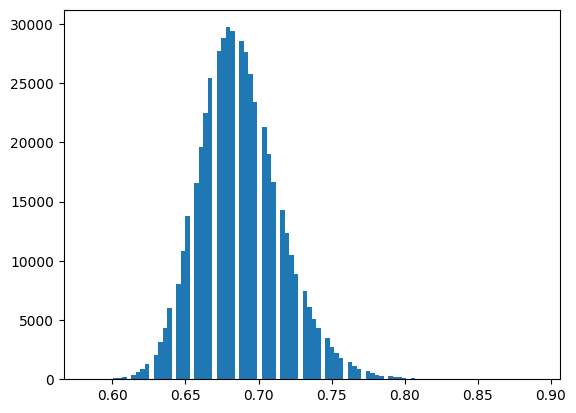

In [13]:
score_int4 = []
for i in range(len(vs_valid)):
    for j in range(i+1, len(vs_valid)):
       
        V1,S1 = quantint4(vs_valid[i:i+1],group_size = 32)
        V2,S2 = quantint4(vs_valid[j:j+1],group_size = 32)
        V1V2 = torch.matmul(V1.to(torch.bfloat16), V2.to(torch.bfloat16).T)
        score_int4.append(torch.sum(torch.diag(V1V2)*S1*S2).item()) 
            
  
plt.hist(score_int4, bins=100)  

#### 4-2. symmetric and group quantization (group_size=64)

(array([1.0000e+00, 3.0000e+00, 1.0000e+00, 6.0000e+00, 0.0000e+00,
        1.9000e+01, 2.9000e+01, 3.7000e+01, 7.9000e+01, 0.0000e+00,
        1.3800e+02, 2.4200e+02, 3.3900e+02, 5.9300e+02, 0.0000e+00,
        8.9200e+02, 1.3590e+03, 2.0460e+03, 3.1400e+03, 0.0000e+00,
        4.4300e+03, 6.1720e+03, 8.3830e+03, 1.0887e+04, 0.0000e+00,
        1.3619e+04, 1.6715e+04, 1.9827e+04, 2.2622e+04, 0.0000e+00,
        2.5590e+04, 2.7461e+04, 2.9320e+04, 2.9279e+04, 0.0000e+00,
        2.9704e+04, 2.8748e+04, 2.7387e+04, 2.5486e+04, 0.0000e+00,
        2.3829e+04, 2.0908e+04, 1.8979e+04, 1.6343e+04, 0.0000e+00,
        1.4220e+04, 1.2076e+04, 1.0435e+04, 8.8700e+03, 0.0000e+00,
        7.2890e+03, 6.2870e+03, 5.1920e+03, 4.2700e+03, 0.0000e+00,
        3.3780e+03, 2.8900e+03, 2.1870e+03, 1.7260e+03, 0.0000e+00,
        1.3400e+03, 1.0980e+03, 8.4500e+02, 6.2100e+02, 0.0000e+00,
        5.3200e+02, 3.5800e+02, 3.1000e+02, 2.3300e+02, 0.0000e+00,
        1.8000e+02, 1.3700e+02, 9.5000e+01, 8.20

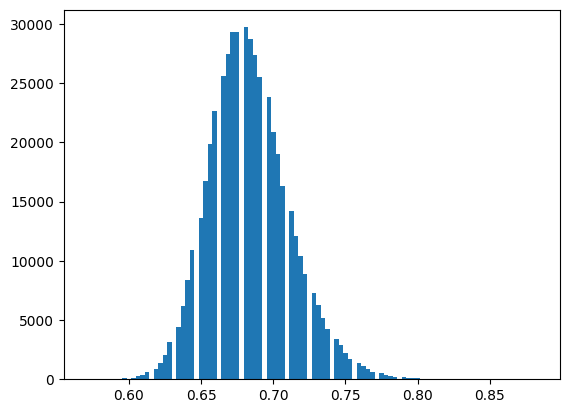

In [14]:
score_int4 = []
for i in range(len(vs_valid)):
    for j in range(i+1, len(vs_valid)):
       
        V1,S1 = quantint4(vs_valid[i:i+1],group_size = 64 )
        V2,S2 = quantint4(vs_valid[j:j+1],group_size = 64)
        V1V2 = torch.matmul(V1.to(torch.bfloat16), V2.to(torch.bfloat16).T)
        score_int4.append(torch.sum(torch.diag(V1V2)*S1*S2).item()) 
            
  
plt.hist(score_int4, bins=100)  

#### 4-3. symmetric and group quantization (group_size=128)

(array([1.0000e+00, 3.0000e+00, 3.0000e+00, 7.0000e+00, 0.0000e+00,
        1.5000e+01, 3.2000e+01, 6.3000e+01, 0.0000e+00, 9.4000e+01,
        1.7000e+02, 2.9400e+02, 4.8700e+02, 0.0000e+00, 7.7800e+02,
        1.1250e+03, 1.7970e+03, 0.0000e+00, 2.6770e+03, 4.1790e+03,
        5.4910e+03, 0.0000e+00, 7.7050e+03, 1.0159e+04, 1.3337e+04,
        1.5745e+04, 0.0000e+00, 1.9682e+04, 2.2268e+04, 2.5579e+04,
        0.0000e+00, 2.7064e+04, 3.0016e+04, 2.9751e+04, 0.0000e+00,
        3.0552e+04, 2.9111e+04, 2.8856e+04, 2.6232e+04, 0.0000e+00,
        2.4705e+04, 2.1312e+04, 1.9628e+04, 0.0000e+00, 1.6805e+04,
        1.4885e+04, 1.2010e+04, 0.0000e+00, 1.0725e+04, 8.7120e+03,
        7.6010e+03, 6.0270e+03, 0.0000e+00, 5.0730e+03, 4.0040e+03,
        3.4070e+03, 0.0000e+00, 2.4540e+03, 2.0740e+03, 1.5780e+03,
        0.0000e+00, 1.2590e+03, 9.0900e+02, 7.5200e+02, 5.2700e+02,
        0.0000e+00, 4.3200e+02, 3.2400e+02, 2.5200e+02, 0.0000e+00,
        1.8800e+02, 1.5600e+02, 1.1300e+02, 0.00

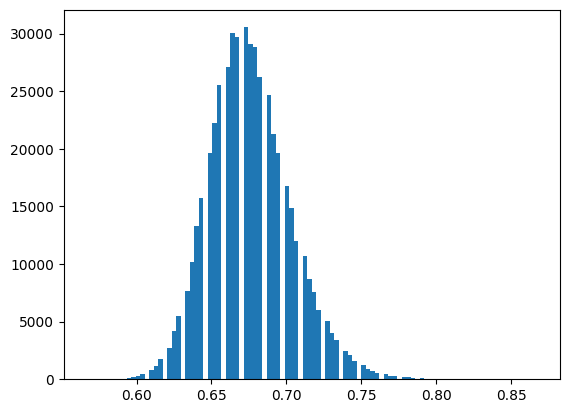

In [15]:
score_int4 = []
for i in range(len(vs_valid)):
    for j in range(i+1, len(vs_valid)):
       
        V1,S1 = quantint4(vs_valid[i:i+1],group_size = 128 )
        V2,S2 = quantint4(vs_valid[j:j+1],group_size = 128)
        V1V2 = torch.matmul(V1.to(torch.bfloat16), V2.to(torch.bfloat16).T)
        score_int4.append(torch.sum(torch.diag(V1V2)*S1*S2).item()) 
            
  
plt.hist(score_int4, bins=100)  

#### 4-4. symmetric and group quantization (group_size=256)

(array([1.0000e+00, 1.0000e+00, 2.0000e+00, 0.0000e+00, 4.0000e+00,
        8.0000e+00, 1.8000e+01, 0.0000e+00, 4.2000e+01, 6.3000e+01,
        1.1500e+02, 0.0000e+00, 2.2000e+02, 3.9200e+02, 0.0000e+00,
        6.5000e+02, 9.8700e+02, 1.5630e+03, 0.0000e+00, 2.2760e+03,
        3.5980e+03, 4.9670e+03, 0.0000e+00, 7.4740e+03, 9.3910e+03,
        0.0000e+00, 1.2930e+04, 1.5125e+04, 1.9860e+04, 0.0000e+00,
        2.2151e+04, 2.6922e+04, 2.7714e+04, 0.0000e+00, 3.1649e+04,
        3.0713e+04, 3.3636e+04, 0.0000e+00, 3.0051e+04, 3.1042e+04,
        0.0000e+00, 2.6468e+04, 2.6605e+04, 2.1220e+04, 0.0000e+00,
        2.0566e+04, 1.6287e+04, 1.5091e+04, 0.0000e+00, 1.1303e+04,
        1.0449e+04, 0.0000e+00, 7.7570e+03, 7.0560e+03, 4.9900e+03,
        0.0000e+00, 4.5130e+03, 3.1350e+03, 2.7410e+03, 0.0000e+00,
        1.8130e+03, 1.5900e+03, 0.0000e+00, 1.0460e+03, 8.7200e+02,
        5.4600e+02, 0.0000e+00, 5.4700e+02, 3.3200e+02, 2.7900e+02,
        0.0000e+00, 1.8000e+02, 1.4400e+02, 9.70

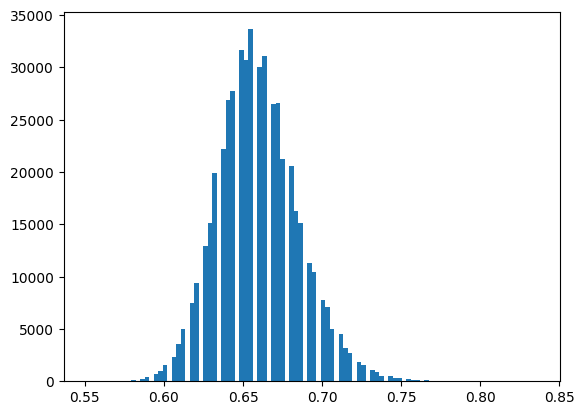

In [16]:
score_int4 = []
for i in range(len(vs_valid)):
    for j in range(i+1, len(vs_valid)):
       
        V1,S1 = quantint4(vs_valid[i:i+1],group_size = 256 )
        V2,S2 = quantint4(vs_valid[j:j+1],group_size = 256)
        V1V2 = torch.matmul(V1.to(torch.bfloat16), V2.to(torch.bfloat16).T)
        score_int4.append(torch.sum(torch.diag(V1V2)*S1*S2).item()) 
            
  
plt.hist(score_int4, bins=100)  